In [14]:
# Importy i konfiguracja
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Sciezki
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_PATH = os.path.join(NOTEBOOK_DIR, '..', '..', 'data')
MODELS_PATH = os.path.join(NOTEBOOK_DIR, '..', '..', 'src', 'models')

# Sprawdzenie sciezek
print(f"\nDane: {os.path.abspath(DATA_PATH)}")
print(f"Modele: {os.path.abspath(MODELS_PATH)}")

# Zdjecia testowe (pelne, nie tile'e)
TEST_IMG_PATH = os.path.join(DATA_PATH, 'processed/split/test/images/raw')
TEST_MASK_PATH = os.path.join(DATA_PATH, 'processed/split/test/masks/raw')

print(f"\nZdjecia testowe: {len(os.listdir(TEST_IMG_PATH))} plikow")

Device: cpu

Dane: /home/cymo/Graphite_segmentation_system/App/data
Modele: /home/cymo/Graphite_segmentation_system/App/src/models

Zdjecia testowe: 56 plikow


In [15]:
# Architektura U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)


class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(2)
    
    def forward(self, x):
        skip = self.conv(x)
        pooled = self.pool(skip)
        return skip, pooled


class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)
        self.conv = DoubleConv(out_channels * 2, out_channels)
    
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)
        self.bottleneck = DoubleConv(512, 1024)
        self.dec4 = DecoderBlock(1024, 512)
        self.dec3 = DecoderBlock(512, 256)
        self.dec2 = DecoderBlock(256, 128)
        self.dec1 = DecoderBlock(128, 64)
        self.out_conv = nn.Conv2d(64, out_channels, 1)
    
    def forward(self, x):
        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)
        s4, p4 = self.enc4(p3)
        b = self.bottleneck(p4)
        d4 = self.dec4(b, s4)
        d3 = self.dec3(d4, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)
        return self.out_conv(d1)

print("U-Net zdefiniowany")

U-Net zdefiniowany


In [ ]:
# Architektura DeepLabV3+
class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=6, dilation=6, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=12, dilation=12, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=18, dilation=18, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5)
        )

    def forward(self, x):
        size = x.shape[2:]
        feat1 = self.conv1(x)
        feat2 = self.conv2(x)
        feat3 = self.conv3(x)
        feat4 = self.conv4(x)
        feat5 = F.interpolate(self.pool(x), size=size, mode='bilinear', align_corners=False)
        return self.project(torch.cat([feat1, feat2, feat3, feat4, feat5], dim=1))


class DeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=1, pretrained=False):
        super().__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        self.aspp = ASPP(2048, 256)
        self.low_level_proj = nn.Sequential(
            nn.Conv2d(256, 48, 1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True)
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):
        size = x.shape[2:]
        x = self.layer0(x)
        low_level = self.layer1(x)
        x = self.layer2(low_level)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.aspp(x)
        x = F.interpolate(x, size=low_level.shape[2:], mode='bilinear', align_corners=False)
        low_level = self.low_level_proj(low_level)
        x = torch.cat([x, low_level], dim=1)
        x = self.decoder(x)
        x = F.interpolate(x, size=size, mode='bilinear', align_corners=False)
        return x

print("DeepLabV3+ zdefiniowany")

DeepLabV3+ zdefiniowany


In [17]:
# Wczytanie modeli
MODELS_CONFIG = {
    'U-Net (bez filtracji)': {
        'path': os.path.join(MODELS_PATH, 'U-NET_WITHOUT_FILTRATION', 'best_unet_pytorch.pth'),
        'class': UNet,
        'tile_size': 256,
        'use_imagenet_norm': False  # U-Net nie uzywa pretrenowanego backbone
    },
    'U-Net (z filtracja)': {
        'path': os.path.join(MODELS_PATH, 'U-NET_WITH_FILTRATION', 'best_unet_pytorch.pth'),
        'class': UNet,
        'tile_size': 256,
        'use_imagenet_norm': False
    },
    'DeepLabV3+': {
        'path': os.path.join(MODELS_PATH, 'DEEPLABV3_WITH_FILTRATION', 'best_deeplabv3_pytorch.pth'),
        'class': DeepLabV3Plus,
        'tile_size': 512,
        'use_imagenet_norm': True  # ResNet50 wymaga normalizacji ImageNet
    }
}

# Wczytaj wszystkie modele
loaded_models = {}
for name, config in MODELS_CONFIG.items():
    if os.path.exists(config['path']):
        model = config['class']()
        checkpoint = torch.load(config['path'], map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.to(DEVICE)
        model.eval()
        loaded_models[name] = {
            'model': model, 
            'tile_size': config['tile_size'],
            'use_imagenet_norm': config['use_imagenet_norm']
        }
        print(f"Wczytano: {name} (IoU: {checkpoint.get('best_iou', 'N/A'):.4f})")
    else:
        print(f"Brak pliku: {name}")

print(f"\nWczytano {len(loaded_models)} modeli")

Wczytano: U-Net (bez filtracji) (IoU: 0.6608)
Wczytano: U-Net (z filtracja) (IoU: 0.7187)
Wczytano: DeepLabV3+ (IoU: 0.7319)

Wczytano 3 modeli


In [ ]:
# Funkcja predykcji na pelnym obrazie

# Normalizacja ImageNet (dla DeepLabV3+)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def predict_full_image(model, image_path, device, tile_size=256, overlap=64, use_imagenet_norm=False):
    img = Image.open(image_path).convert('RGB')
    img_np = np.array(img)
    h, w = img_np.shape[:2]
    
    # Bufor na predykcje
    pred_sum = np.zeros((h, w), dtype=np.float32)
    count = np.zeros((h, w), dtype=np.float32)
    
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
    
    # Normalizacja ImageNet dla modeli z pretrenowanym ResNet
    if use_imagenet_norm:
        img_tensor = (img_tensor - IMAGENET_MEAN) / IMAGENET_STD
    
    step = tile_size - overlap
    
    model.eval()
    with torch.no_grad():
        for y in range(0, h, step):
            for x in range(0, w, step):
                # granice tile'a
                y_end = min(y + tile_size, h)
                x_end = min(x + tile_size, w)
                y_start = max(0, y_end - tile_size)
                x_start = max(0, x_end - tile_size)
                
                tile = img_tensor[:, y_start:y_end, x_start:x_end]
                
                # Padding
                if tile.shape[1] < tile_size or tile.shape[2] < tile_size:
                    if use_imagenet_norm:
                        # Padding znormalizowany
                        padded = torch.zeros(3, tile_size, tile_size)
                        padded[0] = -IMAGENET_MEAN[0] / IMAGENET_STD[0]
                        padded[1] = -IMAGENET_MEAN[1] / IMAGENET_STD[1]
                        padded[2] = -IMAGENET_MEAN[2] / IMAGENET_STD[2]
                    else:
                        padded = torch.zeros(3, tile_size, tile_size)
                    padded[:, :tile.shape[1], :tile.shape[2]] = tile
                    tile = padded
                
                tile_batch = tile.unsqueeze(0).to(device)
                logits = model(tile_batch)
                pred_tile = torch.sigmoid(logits).squeeze().cpu().numpy()
                
            
                actual_h = y_end - y_start
                actual_w = x_end - x_start
                pred_sum[y_start:y_end, x_start:x_end] += pred_tile[:actual_h, :actual_w]
                count[y_start:y_end, x_start:x_end] += 1
    
    # Usrednienie overlappujacych obszarow
    pred_avg = pred_sum / np.maximum(count, 1)
    return img_np, pred_avg


def calculate_metrics(pred, mask, threshold=0.5):
    pred_bin = pred > threshold
    mask_bin = mask > 127
    
    tp = (pred_bin & mask_bin).sum()
    fp = (pred_bin & ~mask_bin).sum()
    fn = (~pred_bin & mask_bin).sum()
    
    iou = tp / max(tp + fp + fn, 1)
    dice = 2 * tp / max(2 * tp + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    
    return {'iou': iou, 'dice': dice, 'precision': precision, 'recall': recall}

print("Funkcje predykcji gotowe (z normalizacja ImageNet dla DeepLabV3+)")

Funkcje predykcji gotowe (z normalizacja ImageNet dla DeepLabV3+)


In [ ]:
# Wybor zdjec testowych z grafitem
def find_test_images(img_dir, mask_dir, min_graphite_ratio=0.005, max_images=6):
    results = []
    
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    
    for img_file in img_files:
        img_path = os.path.join(img_dir, img_file)
        mask_name = img_file.replace('.jpg', '_mask.jpg')
        mask_path = os.path.join(mask_dir, mask_name)
        
        if os.path.exists(mask_path):
            mask = np.array(Image.open(mask_path).convert('L'))
            ratio = (mask > 127).mean()
            if ratio > min_graphite_ratio:
                results.append({
                    'img_path': img_path,
                    'mask_path': mask_path,
                    'name': img_file,
                    'graphite_ratio': ratio
                })
    
    # Sortuj po ilosci grafitu
    results.sort(key=lambda x: x['graphite_ratio'], reverse=True)
    
    # zroznicowane przyklady
    if len(results) > max_images:
        step = len(results) // max_images
        results = [results[i * step] for i in range(max_images)]
    
    return results

# zdjecia testowe
test_images = find_test_images(TEST_IMG_PATH, TEST_MASK_PATH, max_images=6)
print(f"Wybrano {len(test_images)} zdjec testowych:")
for i, info in enumerate(test_images):
    print(f"  {i+1}. {info['name']} - {info['graphite_ratio']*100:.1f}% grafitu")

Wybrano 6 zdjec testowych:
  1. Wytop II x500 24mm-6.jpg - 17.4% grafitu
  2. Wytop II x500 6mm- 10.jpg - 8.1% grafitu
  3. Wytop I x500 6mm-4.jpg - 5.7% grafitu
  4. Wytop II x500 24mm-5.jpg - 4.8% grafitu
  5. Wytop I x500 6mm-2.jpg - 3.9% grafitu
  6. Wytop II x500 12mm-3.jpg - 2.8% grafitu


Generowanie predykcji...
[1/6] Wytop II x500 24mm-6.jpg
[2/6] Wytop II x500 6mm- 10.jpg
[3/6] Wytop I x500 6mm-4.jpg
[4/6] Wytop II x500 24mm-5.jpg
[5/6] Wytop I x500 6mm-2.jpg
[6/6] Wytop II x500 12mm-3.jpg


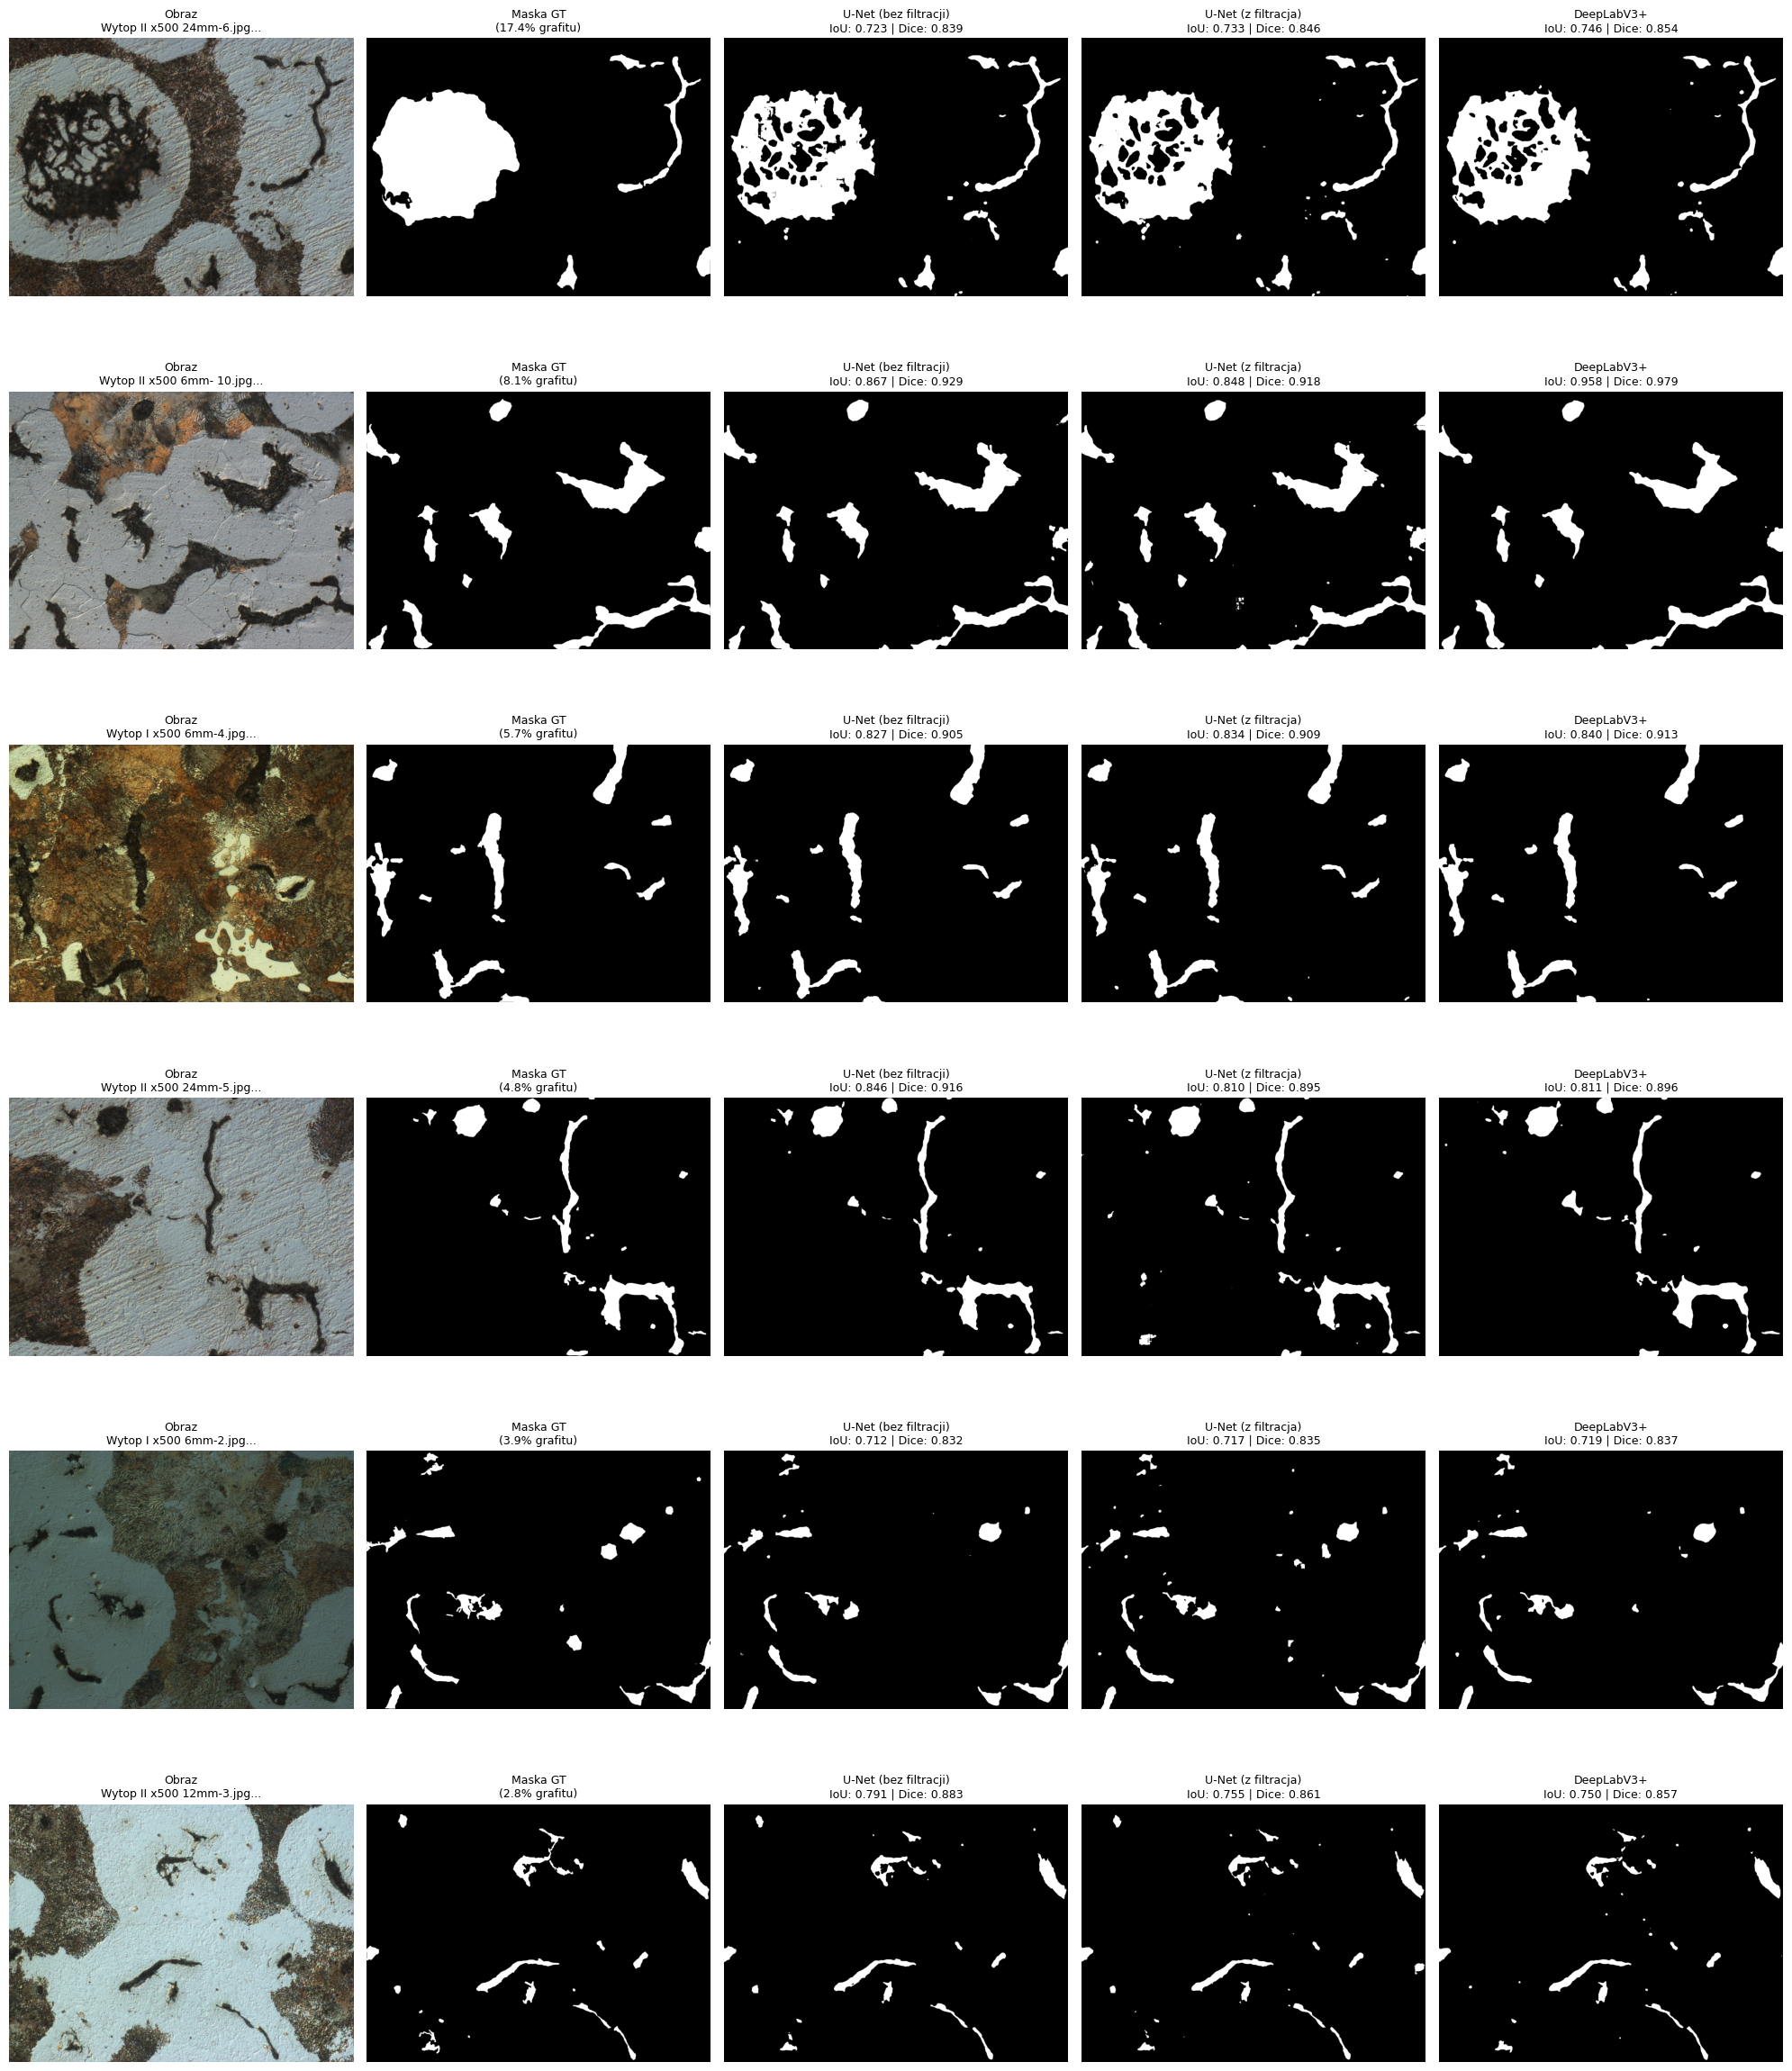


Wizualizacja zapisana!


In [ ]:
# Wizualizacja porownawcza wszystkich modeli
n_images = len(test_images)
n_models = len(loaded_models)

n_cols = 2 + n_models
fig, axes = plt.subplots(n_images, n_cols, figsize=(4 * n_cols, 4 * n_images))

if n_images == 1:
    axes = axes.reshape(1, -1)

# metryki dla kazdego modelu
all_metrics = {name: [] for name in loaded_models.keys()}

# Cache predykcji
predictions_cache = {}

print("Generowanie predykcji...")
for i, info in enumerate(test_images):
    print(f"[{i+1}/{n_images}] {info['name']}")
    
    # Wczytaj maske GT
    mask_np = np.array(Image.open(info['mask_path']).convert('L'))
    
    # Obraz oryginalny
    img_np = np.array(Image.open(info['img_path']).convert('RGB'))
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Obraz\n{info['name'][:25]}...", fontsize=9)
    axes[i, 0].axis('off')
    
    # Maska GT
    axes[i, 1].imshow(mask_np, cmap='gray')
    axes[i, 1].set_title(f"Maska GT\n({info['graphite_ratio']*100:.1f}% grafitu)", fontsize=9)
    axes[i, 1].axis('off')
    
    # Predykcje kazdego modelu
    for j, (model_name, model_data) in enumerate(loaded_models.items()):
        model = model_data['model']
        tile_size = model_data['tile_size']
        use_norm = model_data.get('use_imagenet_norm', False)
        
        # Wiekszy overlap
        cache_key = (info['img_path'], model_name)
        if cache_key not in predictions_cache:
            _, pred = predict_full_image(model, info['img_path'], DEVICE, tile_size=tile_size, overlap=tile_size//2, use_imagenet_norm=use_norm)
            predictions_cache[cache_key] = pred
        else:
            pred = predictions_cache[cache_key]
        
        pred_bin = (pred > 0.5).astype(np.uint8) * 255
        
        # Metryki
        metrics = calculate_metrics(pred, mask_np)
        all_metrics[model_name].append(metrics)
        
        # Wyswietl predykcje
        axes[i, 2 + j].imshow(pred_bin, cmap='gray')
        axes[i, 2 + j].set_title(f"{model_name}\nIoU: {metrics['iou']:.3f} | Dice: {metrics['dice']:.3f}", fontsize=9)
        axes[i, 2 + j].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, '..', '..', 'notebooks', 'visualization', 'comparison_all_models.png'), dpi=150)
plt.show()

print("\nWizualizacja zapisana!")

PODSUMOWANIE METRYK NA ZBIORZE TESTOWYM

U-Net (bez filtracji):
   IoU:       0.7941
   Dice:      0.8840
   Precision: 0.9119
   Recall:    0.8598

U-Net (z filtracja):
   IoU:       0.7830
   Dice:      0.8774
   Precision: 0.8984
   Recall:    0.8587

DeepLabV3+:
   IoU:       0.8041
   Dice:      0.8893
   Precision: 0.9157
   Recall:    0.8662


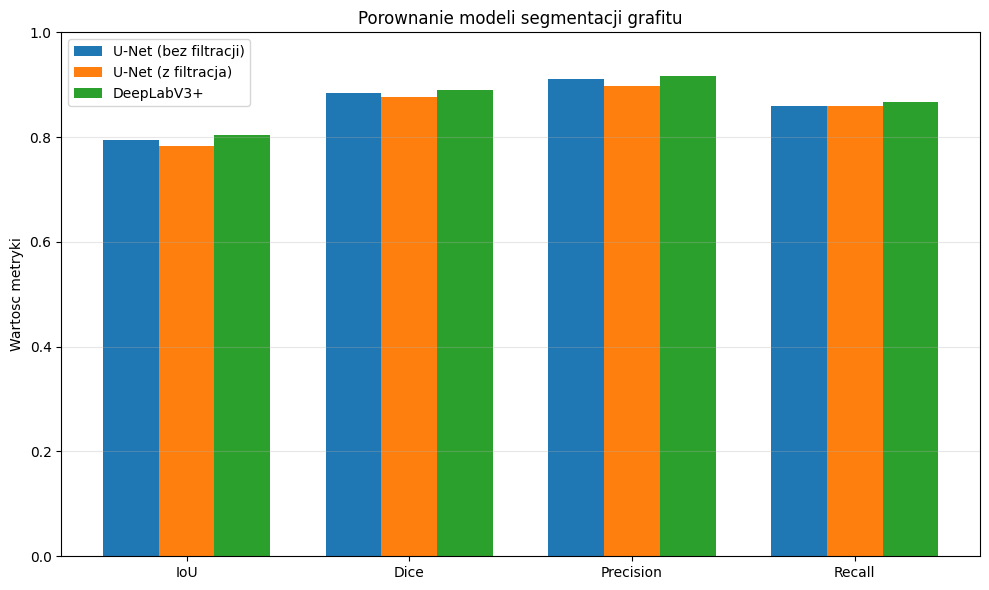


Najlepszy model wg IoU: DeepLabV3+


In [ ]:
# Podsumowanie metryk 
print("PODSUMOWANIE METRYK NA ZBIORZE TESTOWYM")

summary_data = []

for model_name, metrics_list in all_metrics.items():
    avg_iou = np.mean([m['iou'] for m in metrics_list])
    avg_dice = np.mean([m['dice'] for m in metrics_list])
    avg_prec = np.mean([m['precision'] for m in metrics_list])
    avg_rec = np.mean([m['recall'] for m in metrics_list])
    
    summary_data.append({
        'Model': model_name,
        'IoU': avg_iou,
        'Dice': avg_dice,
        'Precision': avg_prec,
        'Recall': avg_rec
    })
    
    print(f"\n{model_name}:")
    print(f"   IoU:       {avg_iou:.4f}")
    print(f"   Dice:      {avg_dice:.4f}")
    print(f"   Precision: {avg_prec:.4f}")
    print(f"   Recall:    {avg_rec:.4f}")

# Wykres
fig, ax = plt.subplots(figsize=(10, 6))

metrics_names = ['IoU', 'Dice', 'Precision', 'Recall']
x = np.arange(len(metrics_names))
width = 0.25

for i, data in enumerate(summary_data):
    values = [data['IoU'], data['Dice'], data['Precision'], data['Recall']]
    ax.bar(x + i * width, values, width, label=data['Model'])

ax.set_ylabel('Wartosc metryki')
ax.set_title('Porownanie modeli segmentacji grafitu')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, '..', '..', 'notebooks', 'visualization', 'metrics_comparison.png'), dpi=150)
plt.show()

print("Najlepszy model wg IoU:", max(summary_data, key=lambda x: x['IoU'])['Model'])

Szczegolowa analiza: Wytop II x500 24mm-6.jpg


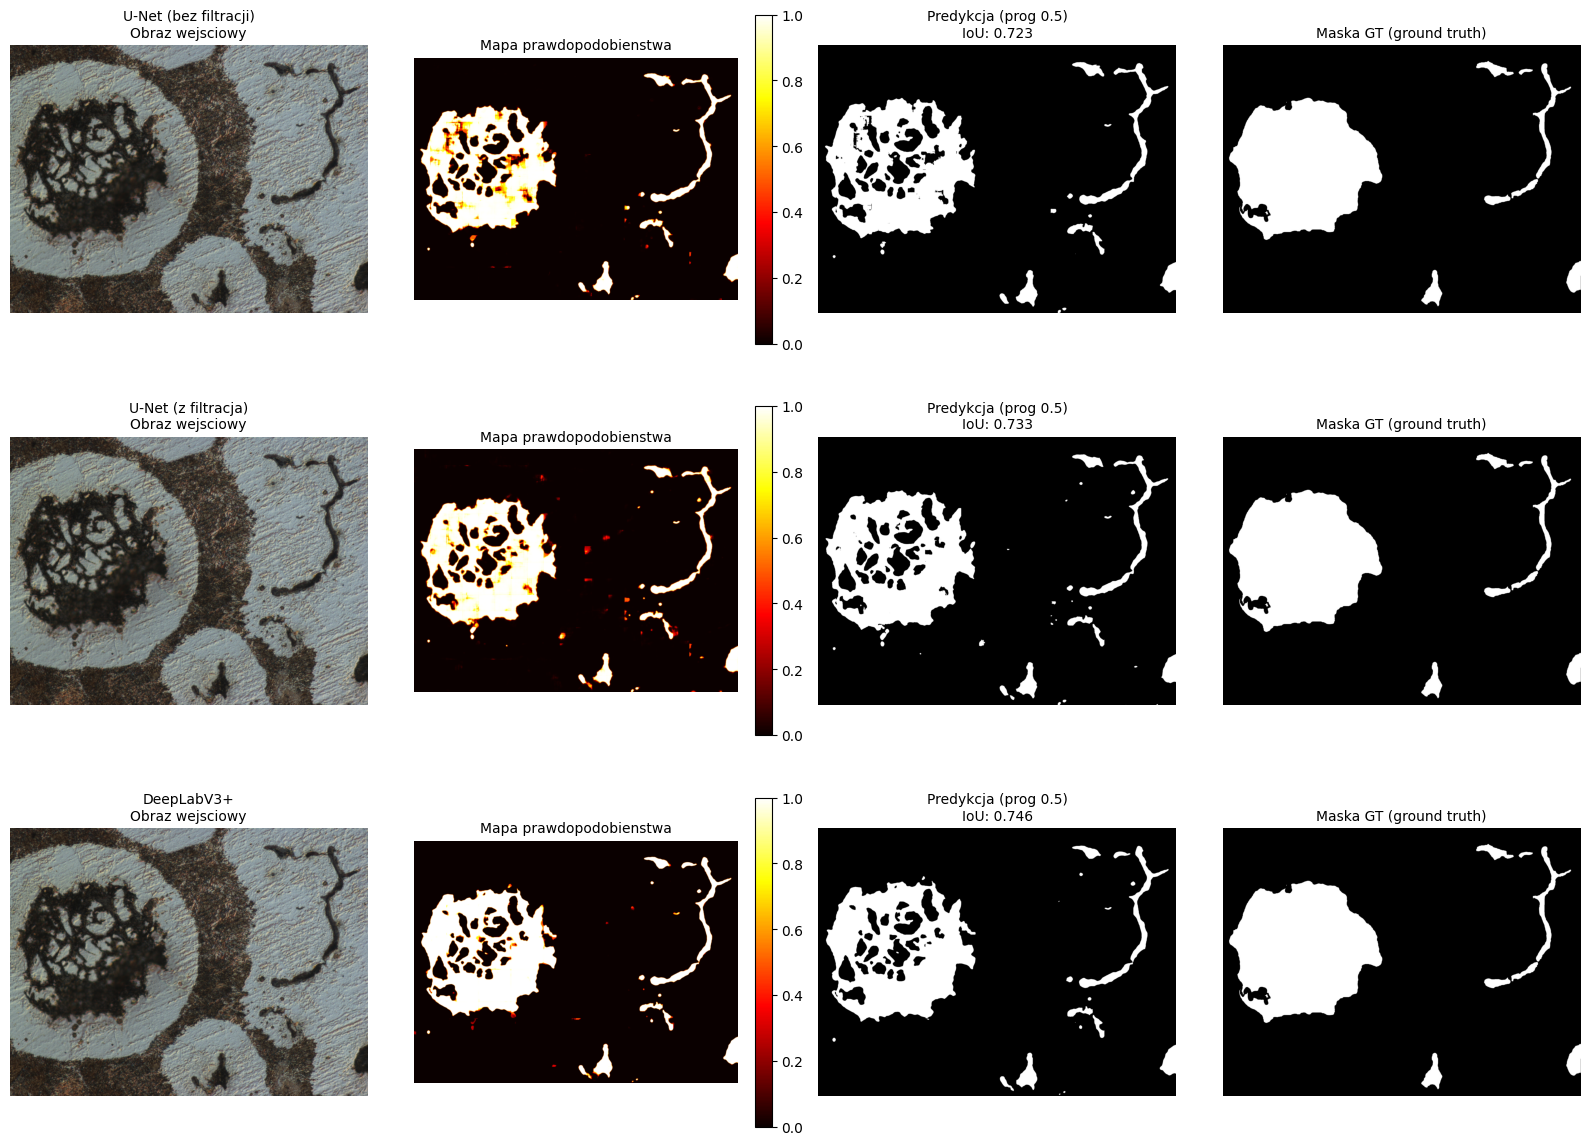

In [ ]:
# Wizualizacja szczegolowa - mapa prawdopodobienstwa vs binaryzacja

selected_idx = 0  # zdjecie
info = test_images[selected_idx]

print(f"Szczegolowa analiza: {info['name']}")

n_models = len(loaded_models)
fig, axes = plt.subplots(n_models, 4, figsize=(16, 4 * n_models))

if n_models == 1:
    axes = axes.reshape(1, -1)

img_np = np.array(Image.open(info['img_path']).convert('RGB'))
mask_np = np.array(Image.open(info['mask_path']).convert('L'))

for i, (model_name, model_data) in enumerate(loaded_models.items()):
    model = model_data['model']
    tile_size = model_data['tile_size']
    use_norm = model_data.get('use_imagenet_norm', False)
    
    # Uzyj cache jesli dostepny
    cache_key = (info['img_path'], model_name)
    if cache_key in predictions_cache:
        pred = predictions_cache[cache_key]
    else:
        _, pred = predict_full_image(model, info['img_path'], DEVICE, tile_size=tile_size, overlap=tile_size//2, use_imagenet_norm=use_norm)
        predictions_cache[cache_key] = pred
    
    pred_bin = (pred > 0.5).astype(np.uint8) * 255
    metrics = calculate_metrics(pred, mask_np)
    
    # Obraz oryginalny
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"{model_name}\nObraz wejsciowy", fontsize=10)
    axes[i, 0].axis('off')
    
    # Mapa prawdopodobienstwa
    im = axes[i, 1].imshow(pred, cmap='hot', vmin=0, vmax=1)
    axes[i, 1].set_title("Mapa prawdopodobienstwa", fontsize=10)
    axes[i, 1].axis('off')
    plt.colorbar(im, ax=axes[i, 1], fraction=0.046)
    
    # Predykcja binarna
    axes[i, 2].imshow(pred_bin, cmap='gray')
    axes[i, 2].set_title(f"Predykcja (prog 0.5)\nIoU: {metrics['iou']:.3f}", fontsize=10)
    axes[i, 2].axis('off')
    
    # Maska GT
    axes[i, 3].imshow(mask_np, cmap='gray')
    axes[i, 3].set_title("Maska GT (ground truth)", fontsize=10)
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, '..', '..', 'notebooks', 'visualization', 'detailed_analysis.png'), dpi=150)
plt.show()

Generowanie map bledow...


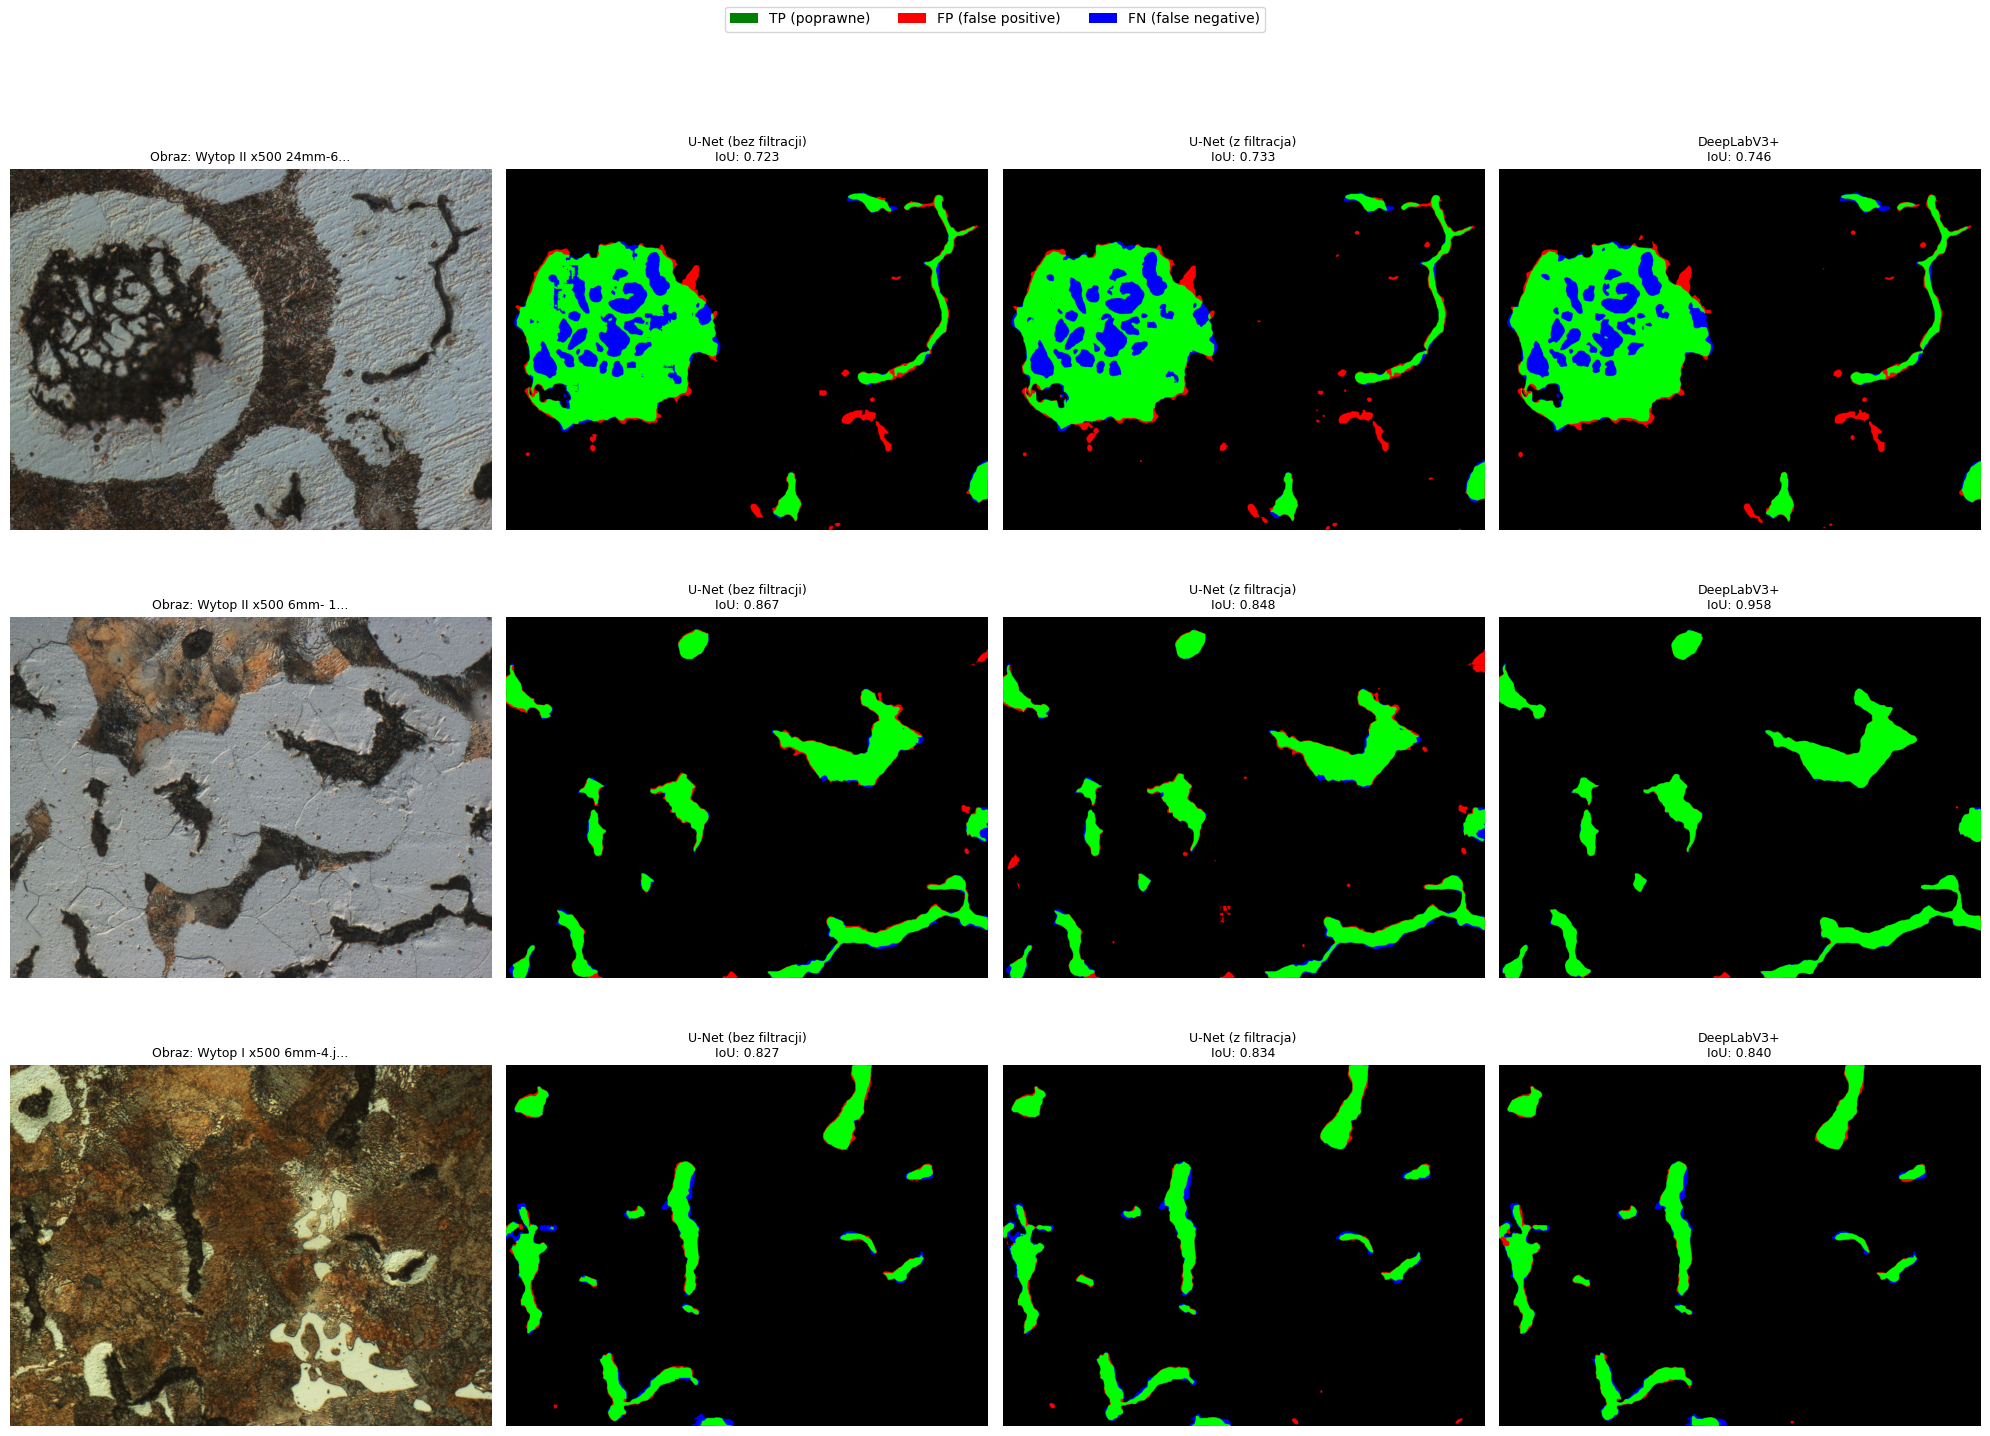

Mapy bledow zapisane!


In [ ]:
#porownanie predykcji z GT (TP, FP, FN)
def create_error_map(pred, mask, threshold=0.5):
    pred_bin = pred > threshold
    mask_bin = mask > 127
    
    error_map = np.zeros((*mask.shape, 3), dtype=np.uint8)
    
    # True Positive - poprawnie wykryty grafit (zielony)
    tp_mask = pred_bin & mask_bin
    error_map[tp_mask] = [0, 255, 0]
    
    # False Positive - blednie wykryty grafit (czerwony)
    fp_mask = pred_bin & ~mask_bin
    error_map[fp_mask] = [255, 0, 0]
    
    # False Negative - pominiety grafit (niebieski)
    fn_mask = ~pred_bin & mask_bin
    error_map[fn_mask] = [0, 0, 255]
    
    return error_map

# Wizualizacja map bledow dla kazdego modelu
n_images = min(3, len(test_images))  # Ogranicz do 3 zdjec
n_models = len(loaded_models)

fig, axes = plt.subplots(n_images, n_models + 1, figsize=(5 * (n_models + 1), 5 * n_images))

if n_images == 1:
    axes = axes.reshape(1, -1)

print("Generowanie map bledow...")
for i in range(n_images):
    info = test_images[i]
    mask_np = np.array(Image.open(info['mask_path']).convert('L'))
    img_np = np.array(Image.open(info['img_path']).convert('RGB'))
    
    # Obraz oryginalny
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Obraz: {info['name'][:20]}...", fontsize=9)
    axes[i, 0].axis('off')
    
    for j, (model_name, model_data) in enumerate(loaded_models.items()):
        model = model_data['model']
        tile_size = model_data['tile_size']
        use_norm = model_data.get('use_imagenet_norm', False)
        
        # Uzyj cache jesli dostepny
        cache_key = (info['img_path'], model_name)
        if cache_key in predictions_cache:
            pred = predictions_cache[cache_key]
        else:
            _, pred = predict_full_image(model, info['img_path'], DEVICE, tile_size=tile_size, overlap=tile_size//2, use_imagenet_norm=use_norm)
            predictions_cache[cache_key] = pred
        
        error_map = create_error_map(pred, mask_np)
        metrics = calculate_metrics(pred, mask_np)
        
        axes[i, j + 1].imshow(error_map)
        axes[i, j + 1].set_title(f"{model_name}\nIoU: {metrics['iou']:.3f}", fontsize=9)
        axes[i, j + 1].axis('off')

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='TP (poprawne)'),
    Patch(facecolor='red', label='FP (false positive)'),
    Patch(facecolor='blue', label='FN (false negative)')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig(os.path.join(MODELS_PATH, '..', '..', 'notebooks', 'visualization', 'error_maps.png'), dpi=150)
plt.show()

print("Mapy bledow zapisane!")

In [ ]:
# Ewaluacja na wszystkich zdjeciach testowych
print("Ewaluacja na pelnym zbiorze testowym...")

all_test_images = find_test_images(TEST_IMG_PATH, TEST_MASK_PATH, min_graphite_ratio=0.001, max_images=100)
print(f"Znaleziono {len(all_test_images)} zdjec testowych\n")

full_metrics = {name: [] for name in loaded_models.keys()}

for i, info in enumerate(all_test_images):
    print(f"[{i+1}/{len(all_test_images)}] {info['name'][:30]}...", end='\r')
    mask_np = np.array(Image.open(info['mask_path']).convert('L'))
    
    for model_name, model_data in loaded_models.items():
        model = model_data['model']
        tile_size = model_data['tile_size']
        use_norm = model_data.get('use_imagenet_norm', False)
        
        # Uzyj cache jesli dostepny
        cache_key = (info['img_path'], model_name)
        if cache_key in predictions_cache:
            pred = predictions_cache[cache_key]
        else:
            _, pred = predict_full_image(model, info['img_path'], DEVICE, tile_size=tile_size, overlap=tile_size//2, use_imagenet_norm=use_norm)
            predictions_cache[cache_key] = pred
        
        metrics = calculate_metrics(pred, mask_np)
        full_metrics[model_name].append(metrics)

print("\n")
print("WYNIKI NA PELNYM ZBIORZE TESTOWYM")

for model_name, metrics_list in full_metrics.items():
    avg_iou = np.mean([m['iou'] for m in metrics_list])
    std_iou = np.std([m['iou'] for m in metrics_list])
    avg_dice = np.mean([m['dice'] for m in metrics_list])
    std_dice = np.std([m['dice'] for m in metrics_list])
    avg_prec = np.mean([m['precision'] for m in metrics_list])
    avg_rec = np.mean([m['recall'] for m in metrics_list])
    
    print(f"\n{model_name}:")
    print(f"   IoU:       {avg_iou:.4f} (+/- {std_iou:.4f})")
    print(f"   Dice:      {avg_dice:.4f} (+/- {std_dice:.4f})")
    print(f"   Precision: {avg_prec:.4f}")
    print(f"   Recall:    {avg_rec:.4f}")


Ewaluacja na pelnym zbiorze testowym...
Znaleziono 56 zdjec testowych

[56/56] Wytop II x500 3mm-1.jpg.....pg...

WYNIKI NA PELNYM ZBIORZE TESTOWYM

U-Net (bez filtracji):
   IoU:       0.7048 (+/- 0.1472)
   Dice:      0.8172 (+/- 0.1122)
   Precision: 0.8502
   Recall:    0.8010

U-Net (z filtracja):
   IoU:       0.6843 (+/- 0.1520)
   Dice:      0.8016 (+/- 0.1235)
   Precision: 0.8027
   Recall:    0.8208

DeepLabV3+:
   IoU:       0.7428 (+/- 0.1619)
   Dice:      0.8416 (+/- 0.1172)
   Precision: 0.8726
   Recall:    0.8241



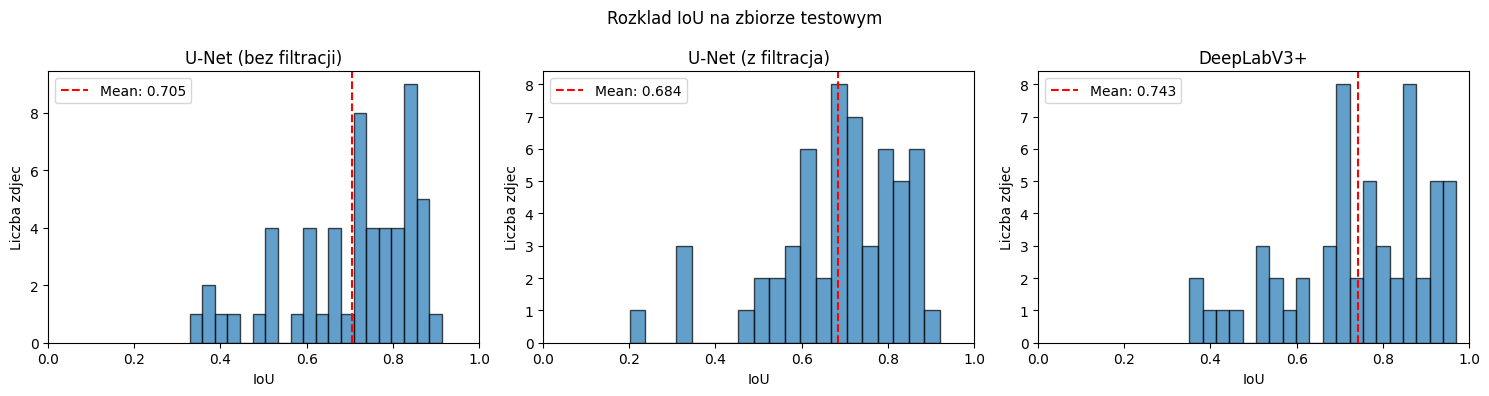

In [ ]:
# Histogram IoU
fig, axes = plt.subplots(1, len(loaded_models), figsize=(5 * len(loaded_models), 4))

if len(loaded_models) == 1:
    axes = [axes]

for i, (model_name, metrics_list) in enumerate(full_metrics.items()):
    iou_values = [m['iou'] for m in metrics_list]
    
    axes[i].hist(iou_values, bins=20, edgecolor='black', alpha=0.7)
    axes[i].axvline(np.mean(iou_values), color='red', linestyle='--', label=f'Mean: {np.mean(iou_values):.3f}')
    axes[i].set_title(f'{model_name}')
    axes[i].set_xlabel('IoU')
    axes[i].set_ylabel('Liczba zdjec')
    axes[i].legend()
    axes[i].set_xlim(0, 1)

plt.suptitle('Rozklad IoU na zbiorze testowym', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(MODELS_PATH, '..', '..', 'notebooks', 'visualization', 'iou_histogram.png'), dpi=150)
plt.show()